# LSTM Malware Detection - CICMalDroid2020

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Setup

In [2]:
import os, time, pickle, warnings, gc, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense,
                                      Dropout, Flatten, Bidirectional,
                                      SpatialDropout1D, GlobalMaxPooling1D,
                                      GlobalAveragePooling1D, Concatenate, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import regularizers, Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

warnings.filterwarnings('ignore')

SAVE_DIR = '/content/drive/MyDrive/LSTM_Demo'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{SAVE_DIR}/figures', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/models', exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Load preprocessed data từ pipeline TCN
TCN_DIR = '/content/drive/MyDrive/MalwareDetection/TCN_V2/'
pkl_path = f'{TCN_DIR}/sequences_deduped_full.pkl'

with open(pkl_path, 'rb') as f:
    compact = pickle.load(f)

encoded_data = compact['encoded_data']
vocab        = compact['vocab']
token2idx    = compact['token2idx']
VOCAB_SIZE   = len(vocab)
PAD_IDX      = token2idx['<PAD>']

# Extract sequences and labels
all_tokens = [d['tokens'] for d in encoded_data]
all_labels = np.array([d['label_binary'] for d in encoded_data])

print(f'Total samples: {len(encoded_data):,}')
print(f'Vocab size: {VOCAB_SIZE}')
print(f'Benign (0): {np.sum(all_labels==0):,}')
print(f'Malware (1): {np.sum(all_labels==1):,}')

# Sequence length stats
seq_lens = [len(t) for t in all_tokens]
print(f'\nSequence lengths:')
print(f'  Min: {min(seq_lens)}, Median: {np.median(seq_lens):.0f}, '
      f'Mean: {np.mean(seq_lens):.0f}, Max: {max(seq_lens)}')
for t in [342, 512, 1024, 2048]:
    pct = sum(1 for l in seq_lens if l <= t) / len(seq_lens) * 100
    print(f'  <= {t}: {pct:.1f}%')

Total samples: 9,449
Vocab size: 111
Benign (0): 1,251
Malware (1): 8,198

Sequence lengths:
  Min: 15, Median: 2602, Mean: 5174, Max: 107666
  <= 342: 0.1%
  <= 512: 6.2%
  <= 1024: 30.8%
  <= 2048: 43.6%


In [4]:
MAX_LEN = 512   # Truncate/pad sequences

X = pad_sequences(all_tokens, maxlen=MAX_LEN, padding='pre',
                  truncating='post', value=PAD_IDX)
Y = all_labels

print(f'X shape: {X.shape}')
print(f'Y shape: {Y.shape}')

# 80/20 split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=RANDOM_STATE, stratify=Y
)

print(f'\nTrain: {X_train.shape[0]:,} (Benign: {np.sum(Y_train==0):,}, Malware: {np.sum(Y_train==1):,})')
print(f'Test:  {X_test.shape[0]:,} (Benign: {np.sum(Y_test==0):,}, Malware: {np.sum(Y_test==1):,})')

X shape: (9449, 512)
Y shape: (9449,)

Train: 7,559 (Benign: 1,001, Malware: 6,558)
Test:  1,890 (Benign: 250, Malware: 1,640)


In [5]:
def build_original_lstm(vocab_size, max_len):
    """
    LSTM original architecture:
    Embedding(16) -> LSTM(100, softsign, return_seq) -> Dropout -> LSTM(100, softsign) -> Flatten -> Dense(2)
    """
    model = Sequential()
    model.add(Input(shape=(max_len,)))
    model.add(Embedding(vocab_size, 16))
    model.add(LSTM(100, activation='softsign', return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(100, activation='softsign'))
    model.add(Flatten())
    model.add(Dense(2, activation='softmax'))
    return model

model_orig = build_original_lstm(VOCAB_SIZE, MAX_LEN)
model_orig.summary()

model_orig.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Convert labels to one-hot
from tensorflow.keras.utils import to_categorical
Y_train_cat = to_categorical(Y_train, 2)
Y_test_cat = to_categorical(Y_test, 2)

callbacks_orig = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f'{SAVE_DIR}/models/lstm_original_best.keras',
                    monitor='val_loss', save_best_only=True, verbose=0)
]

print("\n🚀 Training Original LSTM...")
t0 = time.time()

history_orig = model_orig.fit(
    X_train, Y_train_cat,
    batch_size=64,
    epochs=80,
    validation_data=(X_test, Y_test_cat),
    callbacks=callbacks_orig,
    verbose=1
)

train_time_orig = time.time() - t0
print(f"\n⏱ Training time: {train_time_orig:.1f}s ({train_time_orig/60:.1f}min)")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 512, 16)        │         1,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 512, 100)       │        46,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,178 (504.60 KB)

 Trainable params: 129,178 (504.60 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training Original LSTM...
Epoch 1/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 192ms/step - accuracy: 0.8885 - loss: 0.3496 - val_accuracy: 0.8942 - val_loss: 0.3254 - learning_rate: 0.0010
Epoch 2/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.8993 - loss: 0.3008 - val_accuracy: 0.8958 - val_loss: 0.3219 - learning_rate: 0.0010
Epoch 3/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.9012 - loss: 0.2964 - val_accuracy: 0.9063 - val_loss: 0.3013 - learning_rate: 0.0010
Epoch 4/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.9163 - loss: 0.2690 - val_accuracy: 0.9037 - val_loss: 0.3029 - learning_rate: 0.0010
Epoch 5/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.9013 - loss: 0.2932 - val_accuracy: 0.8947 - val_loss: 0.3138 - learning_rate: 0.0010
Epoch 6/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.9092 - loss: 0.2765 - val_accuracy: 0.9058 - val_loss: 0.2870 - learning_rate: 0.0010
Epoch 7/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 1

In [6]:
def evaluate_model(model, X_test, Y_test, model_name, save_dir):
    """Evaluate binary model and return metrics + figures."""
    Y_pred_prob = model.predict(X_test)
    Y_pred = np.argmax(Y_pred_prob, axis=1)
    Y_prob_pos = Y_pred_prob[:, 1]  # probability of class 1 (malware)

    acc = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred)
    rec = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    auc = roc_auc_score(Y_test, Y_prob_pos)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"{'='*50}")

    print("\nClassification Report:")
    print(classification_report(Y_test, Y_pred, target_names=['Benign', 'Malware']))

    return {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'auc': auc, 'Y_pred': Y_pred, 'Y_prob': Y_prob_pos
    }

results_orig = evaluate_model(model_orig, X_test, Y_test, "LSTM Gốc (Catak et al.)", SAVE_DIR)

60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step

  LSTM Gốc (Catak et al.)
  Accuracy:  0.9291
  Precision: 0.9368
  Recall:    0.9848
  F1-Score:  0.9602
  AUC-ROC:   0.8796

Classification Report:
              precision    recall  f1-score   support

      Benign       0.85      0.56      0.68       250
     Malware       0.94      0.98      0.96      1640

    accuracy                           0.93      1890
   macro avg       0.89      0.77      0.82      1890
weighted avg       0.93      0.93      0.92      1890



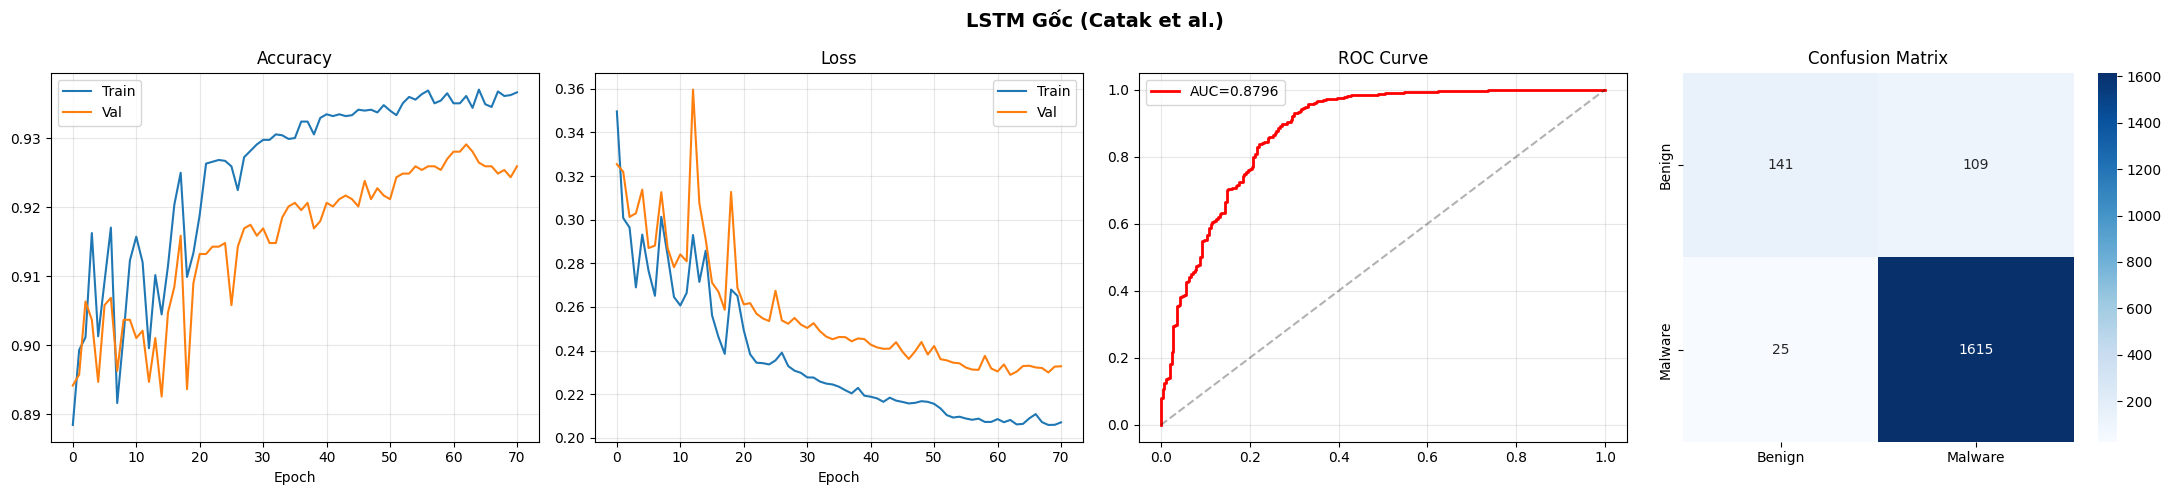

In [7]:
def plot_results(history, Y_test, results, model_name, save_prefix, save_dir):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(model_name, fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_xlabel('Epoch')

    # Loss
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_xlabel('Epoch')

    # ROC
    fpr, tpr, _ = roc_curve(Y_test, results['Y_prob'])
    axes[2].plot(fpr, tpr, 'r-', lw=2, label=f"AUC={results['auc']:.4f}")
    axes[2].plot([0,1],[0,1], 'k--', alpha=0.3)
    axes[2].set_title('ROC Curve'); axes[2].legend(); axes[2].grid(alpha=0.3)

    # Confusion Matrix
    cm = confusion_matrix(Y_test, results['Y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[3],
                xticklabels=['Benign','Malware'], yticklabels=['Benign','Malware'])
    axes[3].set_title('Confusion Matrix')

    plt.tight_layout()
    plt.savefig(f'{save_dir}/figures/{save_prefix}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_results(history_orig, Y_test, results_orig,
             "LSTM Gốc (Catak et al.)", "lstm_original", SAVE_DIR)

In [8]:
def build_improved_lstm(vocab_size, max_len):
    """
    LSTM imporved architecture:
    - Bidirectional LSTM thay vì 2-layer unidirectional
    - SpatialDropout1D trên embedding
    - GlobalMaxPool + GlobalAvgPool thay Flatten (giảm params, tổng quát hơn)
    - Dense head với BatchNorm + Dropout
    """
    inp = Input(shape=(max_len,))
    x = Embedding(vocab_size, 64)(inp)
    x = SpatialDropout1D(0.2)(x)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    # Global pooling thay Flatten — tránh explosion params
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    x = tf.keras.layers.Concatenate()([avg_pool, max_pool])

    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    out = Dense(2, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out)
    return model

model_improved = build_improved_lstm(VOCAB_SIZE, MAX_LEN)
model_improved.summary()

model_improved.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    metrics=['accuracy']
)

callbacks_improved = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f'{SAVE_DIR}/models/lstm_improved_best.keras',
                    monitor='val_loss', save_best_only=True, verbose=0)
]

print("\n🚀 Training Improved LSTM...")
t0 = time.time()

history_improved = model_improved.fit(
    X_train, Y_train_cat,
    batch_size=64,
    epochs=80,
    validation_data=(X_test, Y_test_cat),
    callbacks=callbacks_improved,
    verbose=1
)

train_time_improved = time.time() - t0
print(f"\n⏱ Training time: {train_time_improved:.1f}s ({train_time_improved/60:.1f}min)")

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 512, 64)   │      7,104 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 512, 64)   │          0 │ embedding_1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 512, 256)  │    197,632 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ dropout_1[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ dropout_1[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     65,664 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2)         │        258 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 271,170 (1.03 MB)

 Trainable params: 270,914 (1.03 MB)

 Non-trainable params: 256 (1.00 KB)


🚀 Training Improved LSTM...
Epoch 1/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.8845 - loss: 0.3093 - val_accuracy: 0.8677 - val_loss: 0.4122 - learning_rate: 0.0010
Epoch 2/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9436 - loss: 0.1487 - val_accuracy: 0.8677 - val_loss: 0.4424 - learning_rate: 0.0010
Epoch 3/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9513 - loss: 0.1345 - val_accuracy: 0.8677 - val_loss: 0.3594 - learning_rate: 0.0010
Epoch 4/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9569 - loss: 0.1233 - val_accuracy: 0.8677 - val_loss: 0.2558 - learning_rate: 0.0010
Epoch 5/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9554 - loss: 0.1188 - val_accuracy: 0.9381 - val_loss: 0.1408 - learning_rate: 0.0010
Epoch 6/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9612 - loss: 0.1109 - val_accuracy: 0.9619 - val_loss: 0.1060 - learning_rate: 0.0010
Epoch 7/80
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step

### Phần 2: Evaluation

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

  LSTM Cải tiến
  Accuracy:  0.9704
  Precision: 0.9743
  Recall:    0.9921
  F1-Score:  0.9831
  AUC-ROC:   0.9917

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.83      0.88       250
     Malware       0.97      0.99      0.98      1640

    accuracy                           0.97      1890
   macro avg       0.96      0.91      0.93      1890
weighted avg       0.97      0.97      0.97      1890



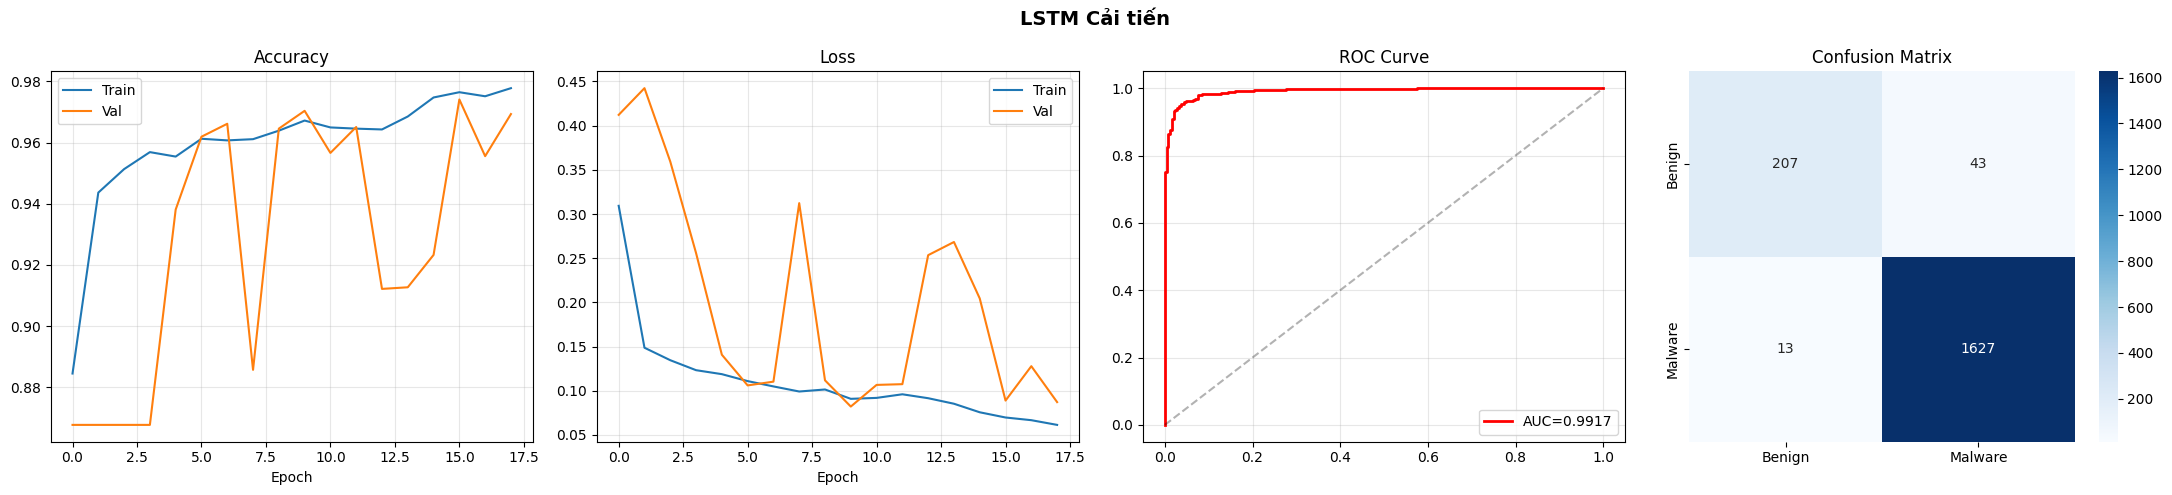

In [9]:
results_improved = evaluate_model(model_improved, X_test, Y_test,
                                   "LSTM Cải tiến", SAVE_DIR)

plot_results(history_improved, Y_test, results_improved,
             "LSTM Cải tiến", "lstm_improved", SAVE_DIR)

In [10]:

print("\n" + "="*70)
print(f"{'Metric':<15s} {'LSTM Gốc':>15s} {'LSTM Cải tiến':>15s} {'Δ':>10s}")
print("="*70)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    v1 = results_orig[metric]
    v2 = results_improved[metric]
    delta = v2 - v1
    arrow = '↑' if delta > 0 else '↓' if delta < 0 else '='
    print(f"{metric:<15s} {v1:>15.4f} {v2:>15.4f} {arrow}{abs(delta):>8.4f}")

print(f"{'Train time':<15s} {train_time_orig:>13.1f}s {train_time_improved:>13.1f}s")

n_params_orig = model_orig.count_params()
n_params_impr = model_improved.count_params()
print(f"{'Parameters':<15s} {n_params_orig:>15,} {n_params_impr:>15,}")
print("="*70)


Metric                 LSTM Gốc   LSTM Cải tiến          Δ
accuracy                 0.9291          0.9704 ↑  0.0413
precision                0.9368          0.9743 ↑  0.0375
recall                   0.9848          0.9921 ↑  0.0073
f1                       0.9602          0.9831 ↑  0.0229
auc                      0.8796          0.9917 ↑  0.1121
Train time              909.4s         103.7s
Parameters              129,178         271,170


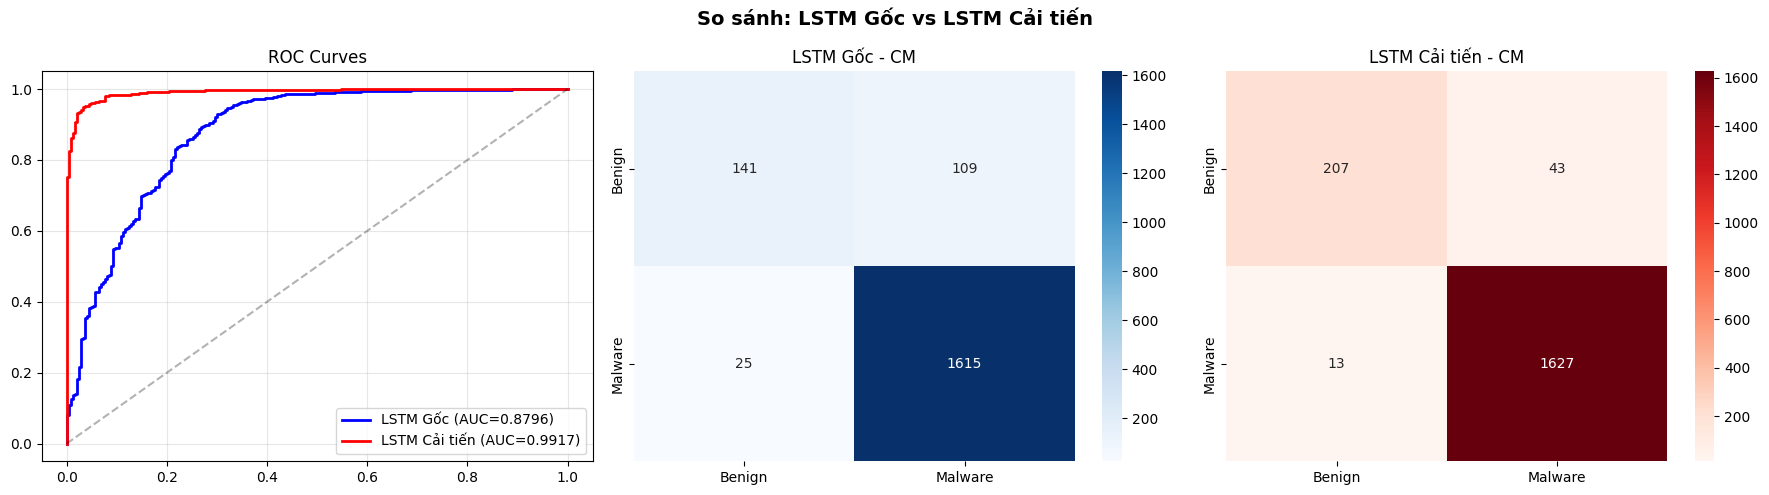

In [11]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('So sánh: LSTM Gốc vs LSTM Cải tiến', fontsize=14, fontweight='bold')


for name, res, color in [('LSTM Gốc', results_orig, 'blue'),
                           ('LSTM Cải tiến', results_improved, 'red')]:
    fpr, tpr, _ = roc_curve(Y_test, res['Y_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={res['auc']:.4f})")
axes[0].plot([0,1],[0,1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curves'); axes[0].legend(); axes[0].grid(alpha=0.3)


cm1 = confusion_matrix(Y_test, results_orig['Y_pred'])
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Benign','Malware'], yticklabels=['Benign','Malware'])
axes[1].set_title('LSTM Gốc - CM')


cm2 = confusion_matrix(Y_test, results_improved['Y_pred'])
sns.heatmap(cm2, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=['Benign','Malware'], yticklabels=['Benign','Malware'])
axes[2].set_title('LSTM Cải tiến - CM')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/comparison_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Save all
import json as _json

summary = {
    'dataset': 'CICMalDroid2020',
    'max_len': MAX_LEN,
    'vocab_size': VOCAB_SIZE,
    'train_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0]),
    'lstm_original': {k: float(v) for k, v in results_orig.items() if k not in ['Y_pred','Y_prob']},
    'lstm_improved': {k: float(v) for k, v in results_improved.items() if k not in ['Y_pred','Y_prob']},
    'train_time_original': train_time_orig,
    'train_time_improved': train_time_improved,
    'params_original': int(n_params_orig),
    'params_improved': int(n_params_impr),
}

with open(f'{SAVE_DIR}/comparison_results.json', 'w') as f:
    _json.dump(summary, f, indent=2)

model_orig.save(f'{SAVE_DIR}/models/lstm_original_final.keras')
model_improved.save(f'{SAVE_DIR}/models/lstm_improved_final.keras')

print("✅ All saved to:", SAVE_DIR)
print("\n📁 Files:")
for root, dirs, files in os.walk(SAVE_DIR):
    for f in sorted(files):
        fpath = os.path.join(root, f)
        sz = os.path.getsize(fpath) / 1024 / 1024
        print(f"  {os.path.relpath(fpath, SAVE_DIR):40s} {sz:6.2f} MB")

✅ All saved to: /content/drive/MyDrive/LSTM_Demo

📁 Files:
  all_results.json                           0.00 MB
  binary_classification_results.csv          0.00 MB
  comparison_results.json                    0.00 MB
  figures/class_distribution.png             0.04 MB
  figures/comparison_lstm.png                0.10 MB
  figures/lstm_improved.png                  0.16 MB
  figures/lstm_original.png                  0.19 MB
  figures/single_lstm_accuracy_loss.png      0.10 MB
  figures/single_lstm_confusion_matrix.png   0.09 MB
  figures/two_lstm_accuracy_loss.png         0.12 MB
  figures/two_lstm_confusion_matrix.png      0.07 MB
  models/binary_Adware.keras                 1.55 MB
  models/binary_Backdoor.keras               1.55 MB
  models/binary_Downloader.keras             1.55 MB
  models/binary_Dropper.keras                1.55 MB
  models/binary_Spyware.keras                1.55 MB
  models/binary_Trojan.keras                 1.55 MB
  models/binary_Virus.keras             